In [1]:
import classy_SIN as classy_pp

#import classy_other as classy


import numpy as np
import matplotlib.pyplot as plt

In [2]:
dict_general={
        'k_output_values': '0.05, 0.002',
        'output':'tCl,pCl,lCl,mPk, mTk',
        'lensing':'yes',
        'start_large_k_at_tau_h_over_tau_k': 0.01,
        'perturbations_verbose':'0',
        'thermodynamics_verbose':'0',
        'z_max_pk': 4.,
        'H0': 67.5,
        'N_ur' : 2.0328,
        'N_ncdm_standard' : 0,
        'omega_b': 0.022,
        'omega_cdm': 0.12,
        'tau_reio': 0.054,
        'ln10^{10}A_s': 3,
        'l_max_scalars': 2500,
        'n_s': 0.965,    
    }

dict_specific = {
        'k_output_values': '0.05, 0.002',
        'output':'tCl,pCl,lCl,mPk, mTk',
        'lensing':'yes',
        'start_large_k_at_tau_h_over_tau_k': 0.01,
        'perturbations_verbose':'0',
        'thermodynamics_verbose':'0',
        'z_max_pk': 4.,
        'H0': 67.5,
        'N_ur' : 2.0328,
        'N_ncdm_standard' : 0,
        'omega_b': 0.022,
        'omega_cdm': 0.12,
        'tau_reio': 0.054,
        'ln10^{10}A_s': 3,
        'l_max_scalars': 2500,
        'n_s': 0.965,
        #Interacting NCDM parameters start
        'N_ncdm_interacting': 1,        
        'deg_ncdm_interacting': 3, #Three degenerate interacting neutrinos with
        'm_ncdm_interacting': 1e-2,
        'ncdm_fluid_approximation': 3,
        'G_eff_ncdm_interacting': 1e-3,
        #Interacting NCDM parameters stop
        #DRMD parameters start
        "G_over_aH_drmd_ini":1e-3,      
        'delta_Neff_drmd':0.1,
        'f_idm_drmd':0.1,
        'z_stop':5000,
        #DRMD parameters end       
    }

    

In [3]:
model_pp = classy_pp.Class(dict_specific)
model_pp.compute()


model_reference = classy_pp.Class(dict_general)
model_reference.compute()

Text(0.5, 1.0, 'Comparison between CLASS++ and CLASS implementation of Hot NEDE and Interacting neutrino model')

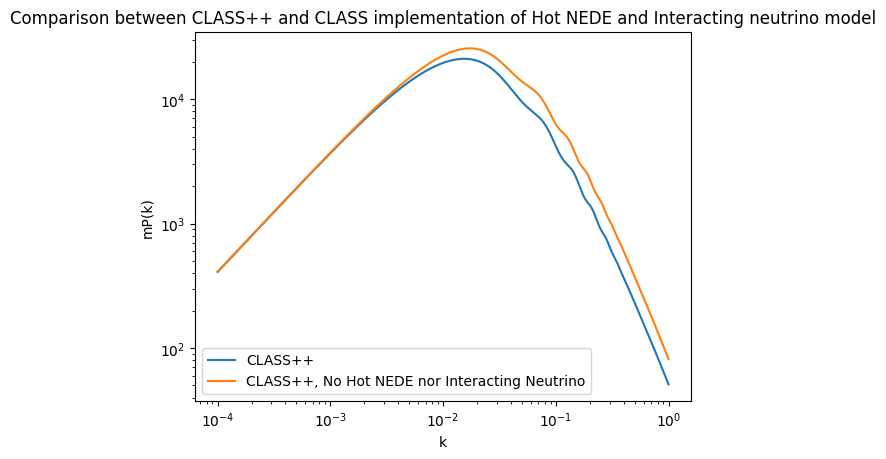

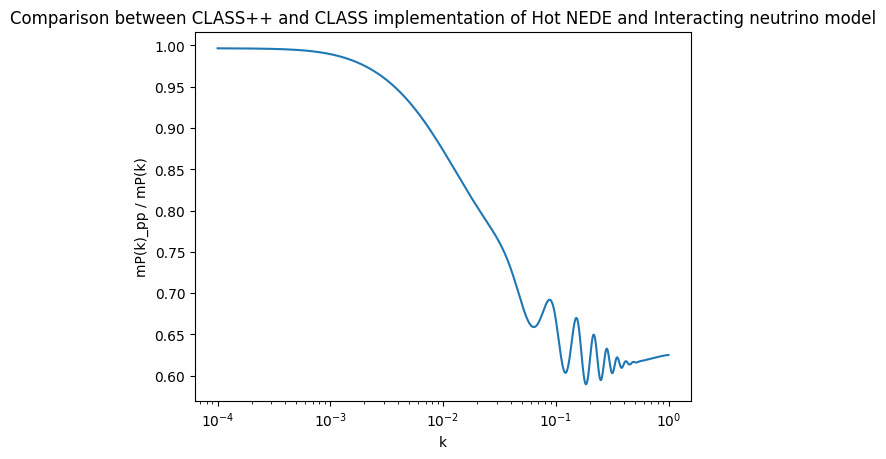

In [4]:
##Matter-Power Spectrum

kmax= 1
klist = np.logspace(-4, np.log10(kmax), 1000)

def mPk(perts):
    pk = np.array([perts.pk(k*perts.h(), 0.)*perts.h()**3 for k in klist])
    return pk

pk_model_pp = mPk(model_pp)
pk_model_reference = mPk(model_reference)


output_data = np.column_stack([
    klist,
    pk_model_pp,
    pk_model_reference
])

np.savetxt(
    "comparison_data/mPk.txt",
    output_data,
    header="k [1/Mpc]    Pk_CLASS++    Pk_reference",
)

fig, ax = plt.subplots()

ax.plot(klist, pk_model_pp, label = "CLASS++")
ax.plot(klist, pk_model_reference, label = "CLASS++, No Hot NEDE nor Interacting Neutrino")
ax.set(yscale='log', xscale='log', xlabel="k", ylabel="mP(k)")
ax.set_title(rf"Comparison between CLASS++ and CLASS implementation of Hot NEDE and Interacting neutrino model")
#ax.set_xscale("log")
ax.legend()

fig, ax = plt.subplots()

ax.plot(klist, (pk_model_pp/pk_model_reference))
ax.set()
ax.set( xscale='log',xlabel="k", ylabel="mP(k)_pp / mP(k)")

ax.set_title(rf"Comparison between CLASS++ and CLASS implementation of Hot NEDE and Interacting neutrino model")



[Text(0.5, 0, '$l$'), Text(0, 0.5, '$C_{l}^{EE}$')]

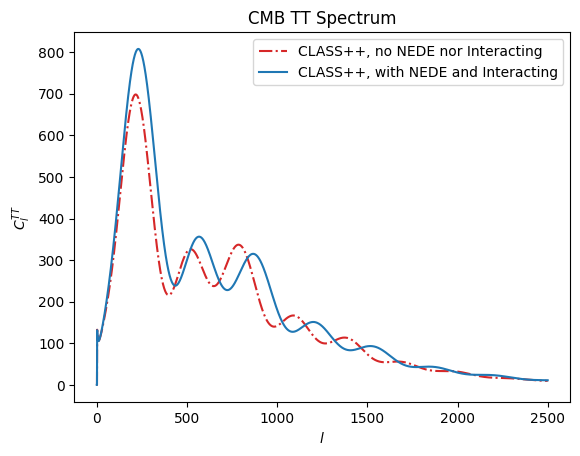

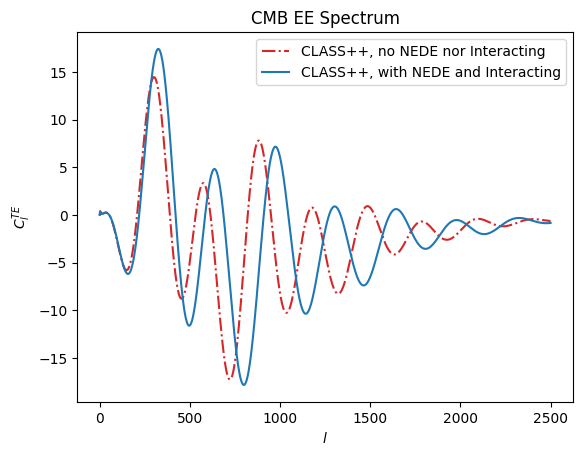

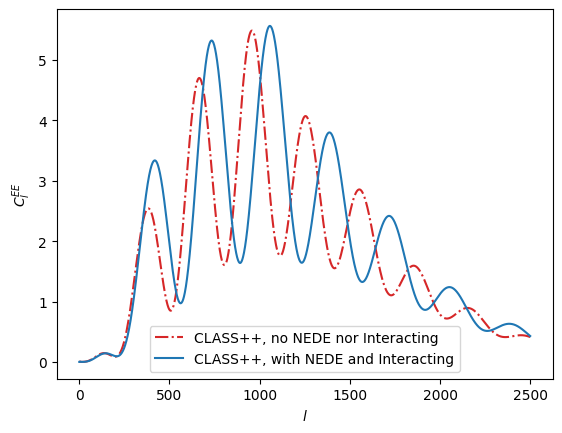

In [12]:
# Get the computed data dictionary
cl = model_pp.lensed_cl()
l = cl['ell']
# Compute D_l = l(l+1)C_l / 2pi (in muK^2)
factor = l * (l + 1) / (2 * np.pi) * 1e12
cl_TT = factor * cl['tt']
cl_TE = factor * cl['te']
cl_EE = factor * cl['ee']

  


fig, ax = plt.subplots()


output_data = np.column_stack([
    l,
    cl_TT,
    cl_TE,
    cl_EE
])

np.savetxt(
    "comparison_data/cls.txt",
    output_data,
    header="l   cl_TT   cl_TE   cl_EE",
)




# Get the computed data dictionary
cl_reference = model_reference.lensed_cl()
l_ref = cl_reference['ell']
# Compute D_l = l(l+1)C_l / 2pi (in muK^2)
factor = l_ref * (l_ref + 1) / (2 * np.pi) * 1e12
cl_TT_ref = factor * cl_reference['tt']
cl_TE_ref = factor * cl_reference['te']
cl_EE_ref = factor * cl_reference['ee']



output_data = np.column_stack([
    l_ref,
    cl_TT_ref,
    cl_TE_ref,
    cl_EE_ref
])

np.savetxt(
    "comparison_data/cls_refernce.txt",
    output_data,
    header="l   cl_TT   cl_TE   cl_EE",
)


# PLOTS: TT Spectra
ax.set_title('CMB TT Spectrum')
ax.plot(l, cl_TT_ref, color='tab:red', label='CLASS++, no NEDE nor Interacting', linestyle = '-.')
ax.plot(l, cl_TT, color='tab:blue', label='CLASS++, with NEDE and Interacting')
ax.legend()
ax.set(xlabel=r'$l$', ylabel = r'$C_{l}^{TT}$')

# PLOTS: TE Spectra
fig,ax = plt.subplots()
ax.set_title('CMB TE Spectrum')
ax.plot(l, cl_TE_ref, color='tab:red', label='CLASS++, no NEDE nor Interacting', linestyle = '-.')
ax.plot(l, cl_TE, color='tab:blue', label='CLASS++, with NEDE and Interacting')
ax.legend()
ax.set(xlabel=r'$l$', ylabel = r'$C_{l}^{TE}$')


# PLOTS: EE Spectra
ax.set_title('CMB EE Spectrum')
fig, ax = plt.subplots()
ax.plot(l, cl_EE_ref, color='tab:red', label='CLASS++, no NEDE nor Interacting', linestyle = '-.')
ax.plot(l, cl_EE, color='tab:blue', label='CLASS++, with NEDE and Interacting')
ax.legend()
ax.set(xlabel=r'$l$', ylabel = r'$C_{l}^{EE}$')


Text(0.5, 0, 'k (h/Mpc)')

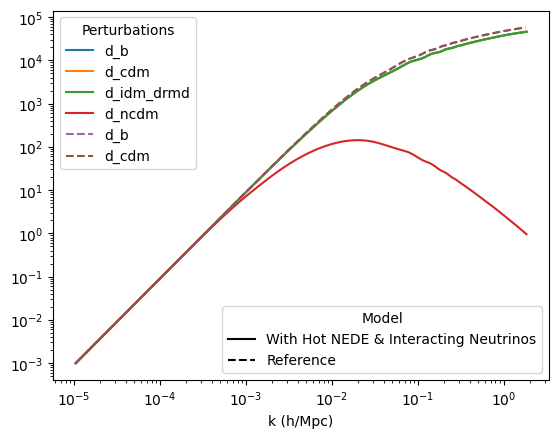

In [6]:

from matplotlib.lines import Line2D

fig, ax = plt.subplots()


mTk = model_pp.get_transfer(z=0)

klist = mTk['k (h/Mpc)']
ax.plot(klist, abs(mTk['d_b']),         linestyle='-', label='d_b')
ax.plot(klist, abs(mTk['d_cdm']),       linestyle='-', label='d_cdm')
ax.plot(klist, abs(mTk['d_idm_drmd']),  linestyle='-', label='d_idm_drmd')
ax.plot(klist, abs(mTk['d_ncdm[0]']),   linestyle='-', label='d_ncdm')

output_data = np.column_stack([
    klist,
    abs(mTk['d_b']),
    abs(mTk['d_cdm']), 
    abs(mTk['d_idm_drmd']),
    abs(mTk['d_ncdm[0]']),
])

np.savetxt(
    "comparison_data/mTk.txt",
    output_data,
    header="k [1/Mpc]   d_b d_idm_drmd  d_ncdm[0] ",
)

mTk = model_reference.get_transfer(z=0)

klist = mTk['k (h/Mpc)']
ax.plot(klist, abs(mTk['d_b']),   linestyle='--', label='d_b')
ax.plot(klist, abs(mTk['d_cdm']), linestyle='--', label='d_cdm')

output_data = np.column_stack([
    klist,
    abs(mTk['d_b']),
    abs(mTk['d_cdm']), 
])

np.savetxt(
    "comparison_data/mTk_reference.txt",
    output_data,
    header="k [1/Mpc]   d_b d_idm_drmd  d_ncdm[0] ",
)





legend_species = ax.legend(title="Perturbations", loc="upper left")


model_handles = [
    Line2D([0], [0], color='black', linestyle='-',  label='With Hot NEDE & Interacting Neutrinos'),
    Line2D([0], [0], color='black', linestyle='--', label='Reference')
]
legend_models = ax.legend(handles=model_handles, title="Model", loc="lower right")


ax.add_artist(legend_species)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k (h/Mpc)')


